In [1]:
import os
import torch
import torchaudio
from torch.utils.data import Dataset
from transformers import AutoProcessor, Wav2Vec2ForSequenceClassification, Trainer, TrainingArguments
import evaluate
import numpy as np
# --------------------
# Dataset definition
# --------------------
class Wav2VecDataset(Dataset):
    def __init__(self, root_dir, processor, target_sr=16000, max_duration=10.0):
        self.files = []
        self.labels = []
        self.processor = processor
        self.target_sr = target_sr
        self.max_length = int(target_sr * max_duration)  # e.g. 160000 samples (10s)

        for fname in os.listdir(root_dir):
            if fname.lower().endswith(".wav"):
                path = os.path.join(root_dir, fname)
                label = 0 if fname.lower().startswith("real_") else 1
                self.files.append(path)
                self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(path)

        # Convert to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Resample if needed
        if sr != self.target_sr:
            waveform = torchaudio.functional.resample(waveform, sr, self.target_sr)

        waveform = waveform.squeeze().numpy()

        # 🔑 Pad or truncate to fixed length
        if len(waveform) > self.max_length:
            waveform = waveform[:self.max_length]
        else:
            pad = self.max_length - len(waveform)
            waveform = np.pad(waveform, (0, pad), mode="constant")

        # Pass to processor
        inputs = self.processor(
            raw_speech=waveform,  # Wav2Vec2/HuBERT need "raw_speech"
            sampling_rate=self.target_sr,
            return_tensors="pt",
            padding=False  # no dynamic padding since we did it ourselves
        )

        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["labels"] = torch.tensor(label, dtype=torch.long)
        return inputs


# --------------------
# Load processor & model
# --------------------
# You can swap in different pretrained checkpoints here:
# - "facebook/wav2vec2-base"
# - "facebook/wav2vec2-large-xlsr-53"
# - "facebook/wav2vec2-base-960h"
checkpoint = "facebook/wav2vec2-base"

processor = AutoProcessor.from_pretrained(checkpoint)

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

# --------------------
# Create datasets
# --------------------
train_dataset = Wav2VecDataset("D:\Thesis\Song\dataset\Train", processor)
valid_dataset = Wav2VecDataset("D:\Thesis\Song\dataset\Valid", processor)
test_dataset  = Wav2VecDataset("D:\Thesis\Song\dataset\Test", processor)

# --------------------
# Metrics
# --------------------
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    }

# --------------------
# Training
# --------------------
training_args = TrainingArguments(
    output_dir="./wav2vec2-finetuned",
    do_eval=True,   # old way to trigger evaluation
    learning_rate=3e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    # logging_steps=100,
    fp16=torch.cuda.is_available(),
    push_to_hub=False
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=processor,
    compute_metrics=compute_metrics
)

print("Starting training...")
trainer.train()

# --------------------
# Evaluation on test set
# --------------------
print("Evaluating on test set...")
metrics = trainer.evaluate(test_dataset)
print(metrics)
from sklearn.metrics import classification_report
import numpy as np

# --------------------
# Evaluation on test set
# --------------------
print("Evaluating on test set...")
metrics = trainer.evaluate(test_dataset)
print(metrics)

# Get predictions for classification report
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

report = classification_report(
    y_true, y_pred,
    target_names=["Real", "AI-Generated"],
    digits=4
)
print(report)

# --------------------
# Save results to file
# --------------------
output_path = "./wav2vec2-finetuned/evaluation_results.txt"
with open(output_path, "w") as f:
    f.write("==== Test Metrics ====\n")
    for k, v in metrics.items():
        f.write(f"{k}: {v:.4f}\n")

    f.write("\n==== Classification Report ====\n")
    f.write(report)

print(f"Saved evaluation results to {output_path}")


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\j3n50\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\j3n50\AppData\Local\Temp\ipykernel_10068\3775042328.py:122: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting training...


...

{'eval_loss': 0.19793182611465454, 'eval_accuracy': 0.9691501746216531, 'eval_f1': 0.9690345074084364, 'eval_runtime': 51.1994, 'eval_samples_per_second': 33.555, 'eval_steps_per_second': 8.399, 'epoch': 3.0}
Evaluating on test set...


c:\Users\j3n50\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\models\wav2vec2\processing_wav2vec2.py:98: UserWarning: Using `raw_speech` as a keyword argument is deprecated. Use `audio` instead.
  warnings.warn("Using `raw_speech` as a keyword argument is deprecated. Use `audio` instead.")


{'eval_loss': 0.19793182611465454, 'eval_accuracy': 0.9691501746216531, 'eval_f1': 0.9690345074084364, 'eval_runtime': 43.4218, 'eval_samples_per_second': 39.565, 'eval_steps_per_second': 9.903, 'epoch': 3.0}


c:\Users\j3n50\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\models\wav2vec2\processing_wav2vec2.py:98: UserWarning: Using `raw_speech` as a keyword argument is deprecated. Use `audio` instead.
  warnings.warn("Using `raw_speech` as a keyword argument is deprecated. Use `audio` instead.")


              precision    recall  f1-score   support

        Real     0.9757    0.9662    0.9709       916
AI-Generated     0.9618    0.9726    0.9671       802

    accuracy                         0.9692      1718
   macro avg     0.9688    0.9694    0.9690      1718
weighted avg     0.9692    0.9692    0.9692      1718

Saved evaluation results to ./wav2vec2-finetuned/evaluation_results.txt


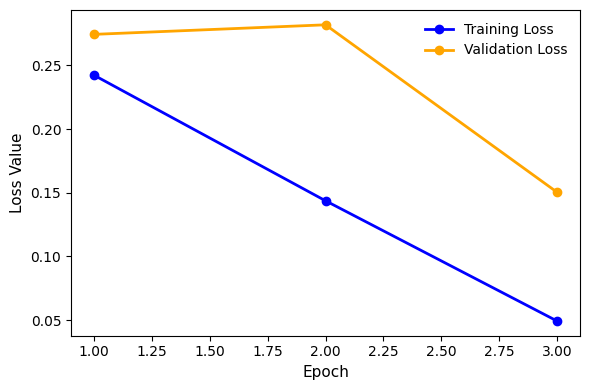

In [3]:
import matplotlib.pyplot as plt

# Data
epochs = [1, 2, 3]
train_loss = [0.242200, 0.143700, 0.049400]
val_loss = [0.274330, 0.281825, 0.150525]

# Create figure
plt.figure(figsize=(6, 4))

# Plot lines (no markers, thin smooth curves)
plt.plot(epochs, train_loss, color='blue', marker='o', markersize=6, linewidth=2, label='Training Loss')
plt.plot(epochs, val_loss, color='orange', marker='o', markersize=6, linewidth=2, label='Validation Loss')

# Labels
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss Value', fontsize=11)

# Remove grid and background boxes
plt.grid(False)
plt.gca().set_facecolor('white')
plt.box(True)

# Legend
plt.legend(frameon=False, fontsize=10, loc='best')

# Tight layout and show
plt.tight_layout()
plt.show()
